In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# Dataset Loading

In [2]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root='/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training',
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root='/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing',
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training Images:", len(train_dataset))
print("Testing Images :", len(test_dataset))

Training Images: 60000
Testing Images : 10000


# Verify Dataset

In [3]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 1, 28, 28])
torch.Size([128])


# Display Sample Images

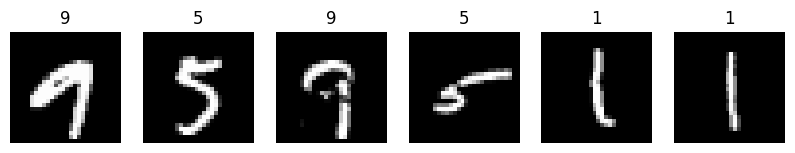

In [4]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1,6, figsize=(10,3))

for i in range(6):

    axes[i].imshow(
        images[i].squeeze(),
        cmap='gray'
    )

    axes[i].set_title(
        labels[i].item()
    )

    axes[i].axis('off')

plt.show()

# Add Gaussian Noise

In [5]:
def add_noise(images):

    noise = torch.randn_like(images) * 0.5

    noisy_images = images + noise

    noisy_images = torch.clamp(
        noisy_images,
        0.,
        1.
    )

    return noisy_images

# Visualize Noise

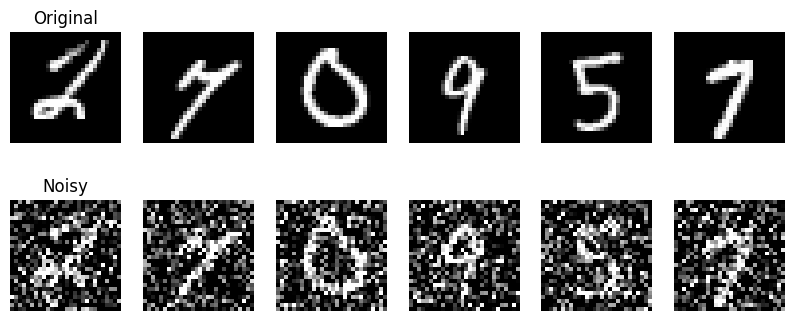

In [6]:
sample_images, _ = next(iter(train_loader))

noisy_images = add_noise(sample_images)

fig, axes = plt.subplots(2,6, figsize=(10,4))

for i in range(6):

    axes[0,i].imshow(
        sample_images[i].squeeze(),
        cmap='gray'
    )
    axes[0,i].axis('off')

    axes[1,i].imshow(
        noisy_images[i].squeeze(),
        cmap='gray'
    )
    axes[1,i].axis('off')

axes[0,0].set_title("Original")
axes[1,0].set_title("Noisy")

plt.show()

# Autoencoder Model

In [7]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2,
                2
            ),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2,
                2
            )
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                32,
                16,
                kernel_size=2,
                stride=2
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                16,
                1,
                kernel_size=2,
                stride=2
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.decoder(x)

        return x

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


# Create Model

In [9]:
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


# Train

In [10]:
epochs = 10

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        noisy_images = add_noise(images)

        optimizer.zero_grad()

        outputs = model(noisy_images)

        loss = criterion(
            outputs,
            images
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.6f}"
    )

Epoch [1/10] Loss: 0.047847
Epoch [2/10] Loss: 0.019174
Epoch [3/10] Loss: 0.017588
Epoch [4/10] Loss: 0.016783
Epoch [5/10] Loss: 0.016268
Epoch [6/10] Loss: 0.015984
Epoch [7/10] Loss: 0.015768
Epoch [8/10] Loss: 0.015598
Epoch [9/10] Loss: 0.015457
Epoch [10/10] Loss: 0.015335


# Plot Loss

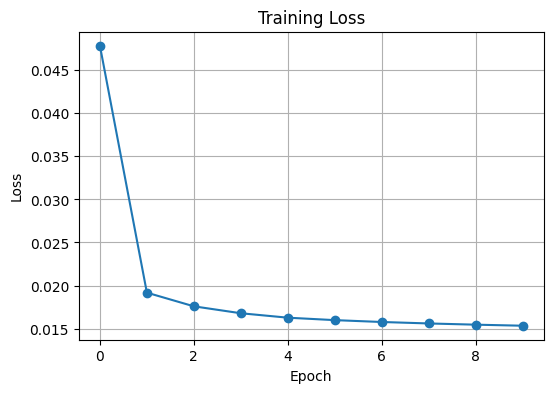

In [11]:
plt.figure(figsize=(6,4))

plt.plot(
    train_losses,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

# Test Model

In [12]:
model.eval()

images, _ = next(iter(test_loader))

images = images.to(device)

noisy_images = add_noise(images)

with torch.no_grad():

    reconstructed = model(
        noisy_images
    )

images = images.cpu()
noisy_images = noisy_images.cpu()
reconstructed = reconstructed.cpu()

# Show Denoising Results

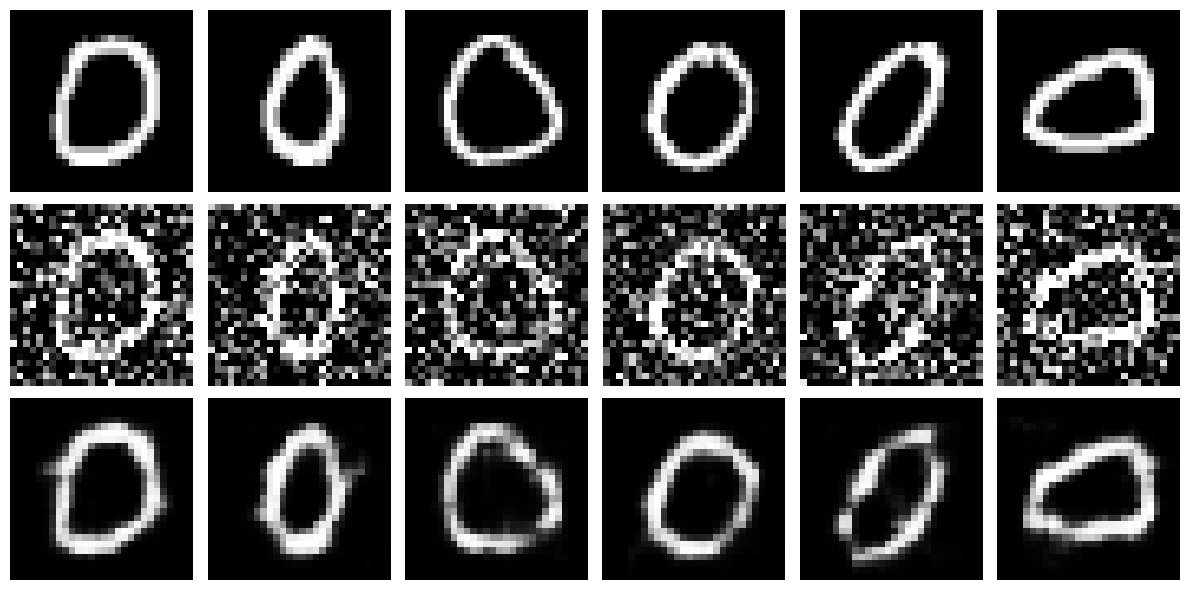

In [13]:
plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(3,6,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

    if i == 0:
        plt.ylabel("Original")

    plt.subplot(3,6,i+7)

    plt.imshow(
        noisy_images[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

    if i == 0:
        plt.ylabel("Noisy")

    plt.subplot(3,6,i+13)

    plt.imshow(
        reconstructed[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

    if i == 0:
        plt.ylabel("Denoised")

plt.tight_layout()

plt.show()

# Save Model

In [14]:
torch.save(
    model.state_dict(),
    "mnist_denoising_autoencoder.pth"
)

print("Model Saved Successfully")

Model Saved Successfully
